#Comparing Prohphet/Machine learning model/ rule-based baseline...

---
### now testing the combination
all done as walk-forward testing...

In [1]:
# ============================================================
# WALK-FORWARD: XGBoost + ElasticNet + 4 Ensemble Strategies
# - XGBoost alone (WF) + plot + metrics
# - ElasticNet alone (WF) + plot + metrics
# - 4 combining strategies (WF-consistent) + plot + metrics
# - Final: all together plot + comparison table
# ============================================================

###data improting

In [2]:
# -----------------------------
# CELL 1) Imports
# -----------------------------
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# -----------------------------
# CELL 2) Download + Load Medical Dataset
# -----------------------------




url_med = "https://drive.google.com/uc?id=1qEID7R4KCgz8QVpgPyQbClUokOT9Yndm"
gdown.download(url_med, "data.csv", quiet=False)
df = pd.read_csv("data.csv")

df["visitdate"] = pd.to_datetime(df["intime_synth"])
df["finishvisitdate"] = pd.to_datetime(df["outtime_synth"])

Downloading...
From: https://drive.google.com/uc?id=1qEID7R4KCgz8QVpgPyQbClUokOT9Yndm
To: /content/data.csv
100%|██████████| 63.1M/63.1M [00:00<00:00, 114MB/s]


In [4]:
# -----------------------------
# CELL 3) Aggregate Daily Patient Arrivals (Target y)
# -----------------------------
daily_arrivals = (
    df.set_index("visitdate")
      .resample("D")
      .size()
      .reset_index(name="y")
      .rename(columns={"visitdate": "ds"})
)

In [5]:
# -----------------------------
# CELL 4) Download + Load Weather Dataset
# -----------------------------
url_w = "https://drive.google.com/uc?id=10SI7ZvJwuStE2zi1OxLiTj-qO76aX6ER"
gdown.download(url_w, "WeatherData.csv", quiet=False)
dfWeather = pd.read_csv("WeatherData.csv")
dfWeather["date"] = pd.to_datetime(dfWeather["time"])

Downloading...
From: https://drive.google.com/uc?id=10SI7ZvJwuStE2zi1OxLiTj-qO76aX6ER
To: /content/WeatherData.csv
100%|██████████| 90.7k/90.7k [00:00<00:00, 23.7MB/s]


In [6]:
# -----------------------------
# CELL 5) Aggregate Daily Mean Temperature
# -----------------------------
daily_temp = (
    dfWeather.groupby("date", as_index=False)
            .agg({"temperature_2m_mean": "mean"})
            .rename(columns={"date": "ds"})
)

In [7]:
# -----------------------------
# CELL 6) Merge Medical + Weather
# -----------------------------
master_df = daily_arrivals.merge(daily_temp, on="ds", how="left")
master_df["ds"] = pd.to_datetime(master_df["ds"])

###train/test

In [8]:
# -----------------------------
# CELL 7) Common Train/Test Split Date (80/20)
# -----------------------------
split_date = master_df["ds"].quantile(0.8)

In [9]:
# -----------------------------
# CELL 8) Build ML Feature Table
# -----------------------------
ml_df = master_df.copy().rename(columns={"ds": "date"})
ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df["dayofweek"] = ml_df["date"].dt.dayofweek
ml_df["month"] = ml_df["date"].dt.month
ml_df["weekofyear"] = ml_df["date"].dt.isocalendar().week.astype(int)

ml_df["y_lag_1"] = ml_df["y"].shift(1)
ml_df["y_lag_7"] = ml_df["y"].shift(7)
ml_df["y_roll_7"] = ml_df["y"].rolling(7).mean()

ml_df.dropna(inplace=True)

features = [
    "temperature_2m_mean",
    "dayofweek",
    "month",
    "weekofyear",
    "y_lag_1",
    "y_lag_7",
    "y_roll_7",
]

train_ml = ml_df[ml_df["date"] <= split_date].copy()
n_train = len(train_ml)

In [10]:
# -----------------------------
# CELL 9) Metrics helpers
# -----------------------------
def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2.0, eps)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100.0

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "N": int(len(y_true)),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MSE": float(mse),
        "R2": float(r2),
        "MAPE(%)": float(mape(y_true, y_pred)),
        "sMAPE(%)": float(smape(y_true, y_pred)),
    }

def plot_one(title, dates, y_true, y_pred, label_pred):
    plt.figure(figsize=(12, 4))
    plt.plot(dates, y_true, label="Actual", linewidth=2)
    plt.plot(dates, y_pred, label=label_pred)
    plt.title(title)
    plt.xlabel("Date"); plt.ylabel("Daily Patients")
    plt.legend(); plt.grid(True); plt.show()

In [11]:
# -----------------------------
# CELL 10) Walk-forward for ML models (re-fit each day)  ✅ WALK-FORWARD
# -----------------------------
def walk_forward_ml(model_factory, df_full, features, n_train):
    dates, y_true_list, y_pred_list = [], [], []

    for i in range(len(df_full) - n_train):
        train_now = df_full.iloc[:n_train + i]              # expanding history
        test_now  = df_full.iloc[n_train + i:n_train + i+1] # one-step ahead

        X_tr = train_now[features]
        y_tr = train_now["y"]
        X_te = test_now[features]
        y_te = test_now["y"].iloc[0]

        model = model_factory()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)[0]

        dates.append(test_now["date"].iloc[0])
        y_true_list.append(y_te)
        y_pred_list.append(pred)

    return np.array(dates), np.array(y_true_list), np.array(y_pred_list)

In [12]:
# -----------------------------
# CELL 11) Model factories
# -----------------------------
def make_xgb():
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )

def make_enet():
    return ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=42)

###XGBoost

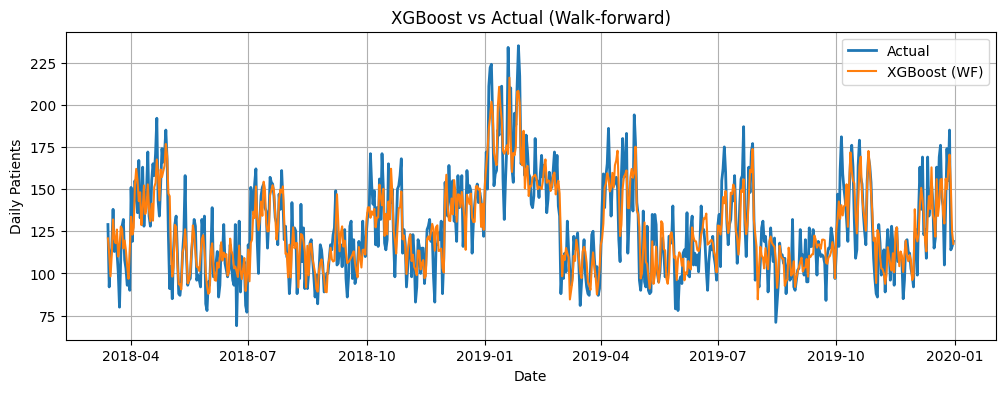

In [13]:
# -----------------------------
# CELL 12) XGBoost alone (WF) + plot + metrics
# -----------------------------
wf_dates_xgb, wf_true, wf_pred_xgb = walk_forward_ml(make_xgb, ml_df, features, n_train)

plot_one("XGBoost vs Actual (Walk-forward)", wf_dates_xgb, wf_true, wf_pred_xgb, "XGBoost (WF)")
xgb_metrics = compute_metrics(wf_true, wf_pred_xgb)

###ElasticNet alone

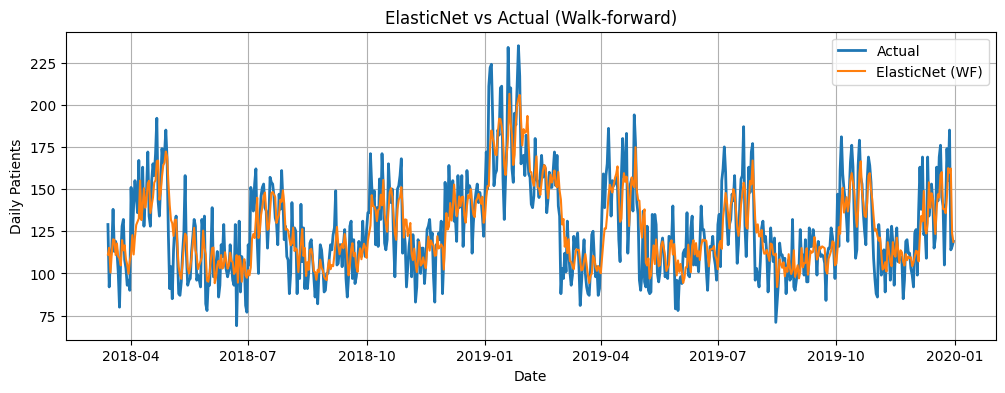

In [14]:
# -----------------------------
# CELL 13) ElasticNet alone (WF) + plot + metrics
# -----------------------------
wf_dates_en, wf_true_en, wf_pred_en = walk_forward_ml(make_enet, ml_df, features, n_train)

# safety: ensure alignment
assert len(wf_true) == len(wf_true_en) and np.all(wf_dates_xgb == wf_dates_en)

plot_one("ElasticNet vs Actual (Walk-forward)", wf_dates_en, wf_true_en, wf_pred_en, "ElasticNet (WF)")
enet_metrics = compute_metrics(wf_true_en, wf_pred_en)

###combining the strategies

In [15]:
# ============================================================
# CELL 14) 4 COMBINING STRATEGIES (ALL ✅ WALK-FORWARD-CONSISTENT)
# ============================================================

dates = wf_dates_xgb
y_true = wf_true
p_xgb = wf_pred_xgb
p_en  = wf_pred_en

# ---------- Strategy 1: Mean ----------
pred_mean = 0.5 * p_xgb + 0.5 * p_en

# ---------- Strategy 2: Weighted (ONLINE) using past MAE only ----------
# At day t: weight is computed from errors up to t-1 (no future).
eps = 1e-8
pred_weighted_online = np.zeros_like(y_true, dtype=float)

for t in range(len(y_true)):
    if t == 0:
        alpha = 0.5  # first day: no history
    else:
        mae_x = np.mean(np.abs(y_true[:t] - p_xgb[:t])) + eps
        mae_e = np.mean(np.abs(y_true[:t] - p_en[:t])) + eps
        # smaller MAE => bigger weight
        w_x = 1.0 / mae_x
        w_e = 1.0 / mae_e
        alpha = w_x / (w_x + w_e)
    pred_weighted_online[t] = alpha * p_xgb[t] + (1 - alpha) * p_en[t]

# ---------- Strategy 3: Stacking (ONLINE) linear meta-model ----------
# At day t: fit meta-model on past (0..t-1), then predict t.
pred_stack_online = np.zeros_like(y_true, dtype=float)
meta = LinearRegression()

for t in range(len(y_true)):
    if t < 5:
        # not enough history => fallback mean
        pred_stack_online[t] = pred_mean[t]
    else:
        X_hist = np.column_stack([p_xgb[:t], p_en[:t]])
        y_hist = y_true[:t]
        meta.fit(X_hist, y_hist)
        pred_stack_online[t] = meta.predict([[p_xgb[t], p_en[t]]])[0]

# ---------- Strategy 4: Residual (ONLINE): EN + correction from XGB ----------
# residual(t) = y(t) - EN(t); learn residual from past vs XGB_pred
pred_residual_online = np.zeros_like(y_true, dtype=float)
res_model = LinearRegression()

for t in range(len(y_true)):
    if t < 5:
        pred_residual_online[t] = pred_mean[t]
    else:
        res_hist = (y_true[:t] - p_en[:t])
        X_hist = p_xgb[:t].reshape(-1, 1)
        res_model.fit(X_hist, res_hist)
        correction = res_model.predict([[p_xgb[t]]])[0]
        pred_residual_online[t] = p_en[t] + correction

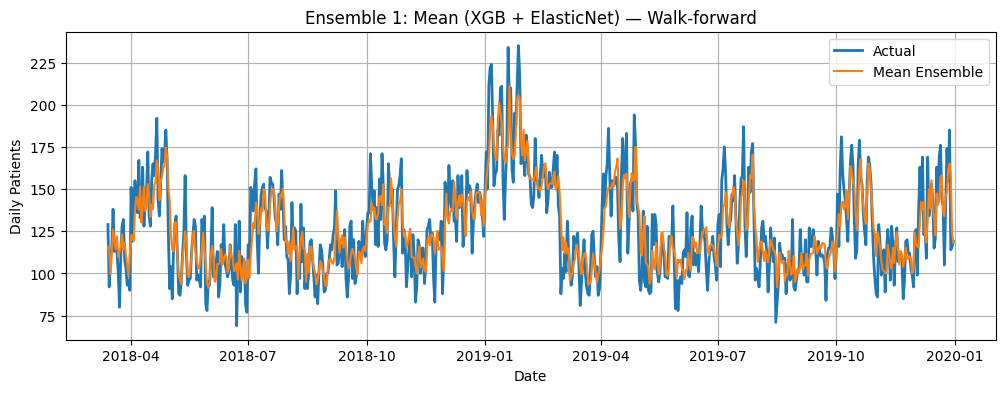

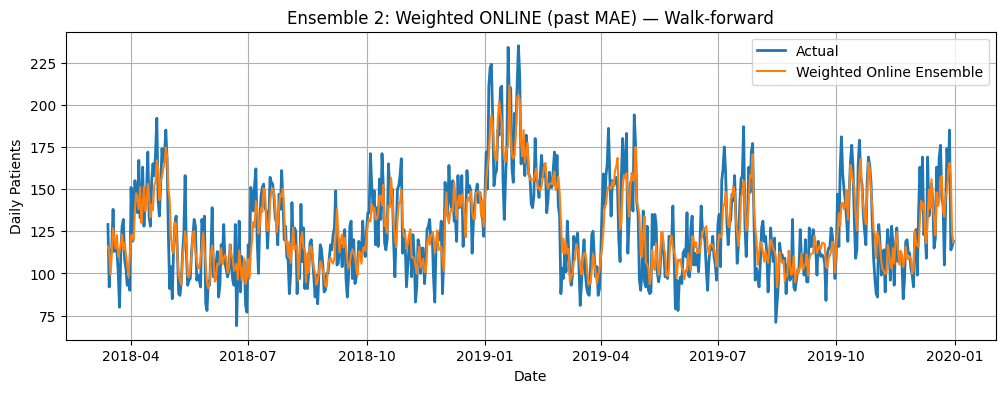

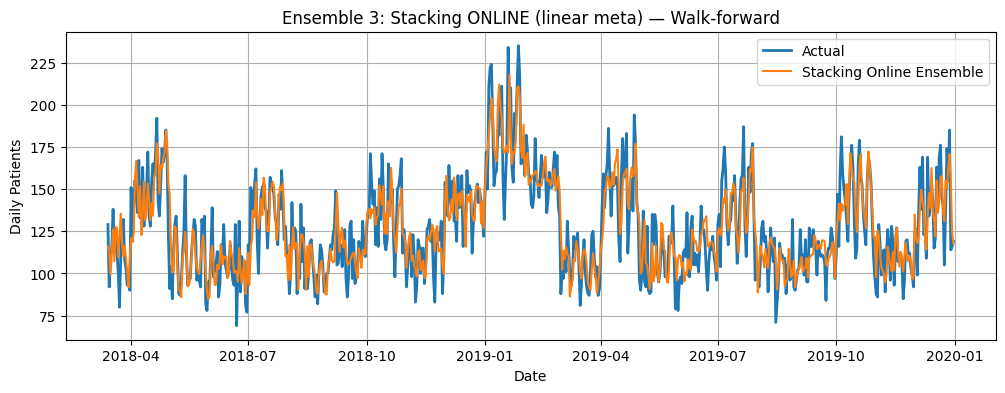

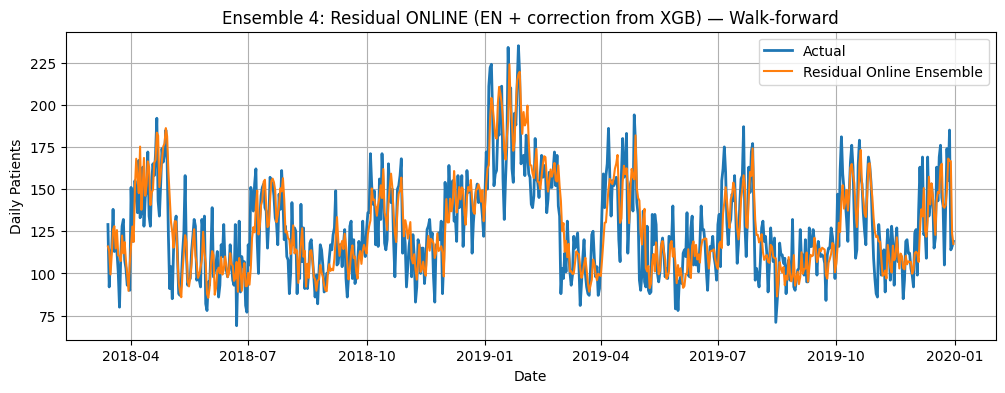

In [16]:
# -----------------------------
# CELL 15) Plot + metrics for each ensemble (separately)
# -----------------------------
plot_one("Ensemble 1: Mean (XGB + ElasticNet) — Walk-forward", dates, y_true, pred_mean, "Mean Ensemble")
plot_one("Ensemble 2: Weighted ONLINE (past MAE) — Walk-forward", dates, y_true, pred_weighted_online, "Weighted Online Ensemble")
plot_one("Ensemble 3: Stacking ONLINE (linear meta) — Walk-forward", dates, y_true, pred_stack_online, "Stacking Online Ensemble")
plot_one("Ensemble 4: Residual ONLINE (EN + correction from XGB) — Walk-forward", dates, y_true, pred_residual_online, "Residual Online Ensemble")

mean_metrics     = compute_metrics(y_true, pred_mean)
wgt_metrics      = compute_metrics(y_true, pred_weighted_online)
stack_metrics    = compute_metrics(y_true, pred_stack_online)
resid_metrics    = compute_metrics(y_true, pred_residual_online)

In [17]:
# -----------------------------
# CELL 16) Numerical metrics table (XGB, EN, 4 ensembles)
# -----------------------------
results_table = pd.DataFrame([
    {"Model": "XGBoost (WF)", **xgb_metrics},
    {"Model": "ElasticNet (WF)", **enet_metrics},
    {"Model": "Ensemble Mean", **mean_metrics},
    {"Model": "Ensemble Weighted ONLINE", **wgt_metrics},
    {"Model": "Ensemble Stacking ONLINE", **stack_metrics},
    {"Model": "Ensemble Residual ONLINE", **resid_metrics},
])

results_table = results_table[["Model","N","MAE","RMSE","MSE","R2","MAPE(%)","sMAPE(%)"]]
results_table = results_table.sort_values("MAE").reset_index(drop=True)
display(results_table)

,Model,N,MAE,RMSE,MSE,R2,MAPE(%),sMAPE(%)
0,XGBoost (WF),658,11.367190,14.614365,213.579651,0.731879,9.280731,9.094728
1,Ensemble Stacking ONLINE,658,11.521909,14.855055,220.672653,0.722974,9.423522,9.232012
2,Ensemble Weighted ONLINE,658,11.694841,15.048682,226.462836,0.715705,9.598057,9.383232
3,Ensemble Mean,658,11.772152,15.143037,229.311575,0.712129,9.664502,9.445911
4,Ensemble Residual ONLINE,658,13.024870,16.844249,283.728709,0.643815,10.670170,10.397606
5,ElasticNet (WF),658,13.334708,17.106630,292.636793,0.632633,10.960521,10.683926


###All in one plot

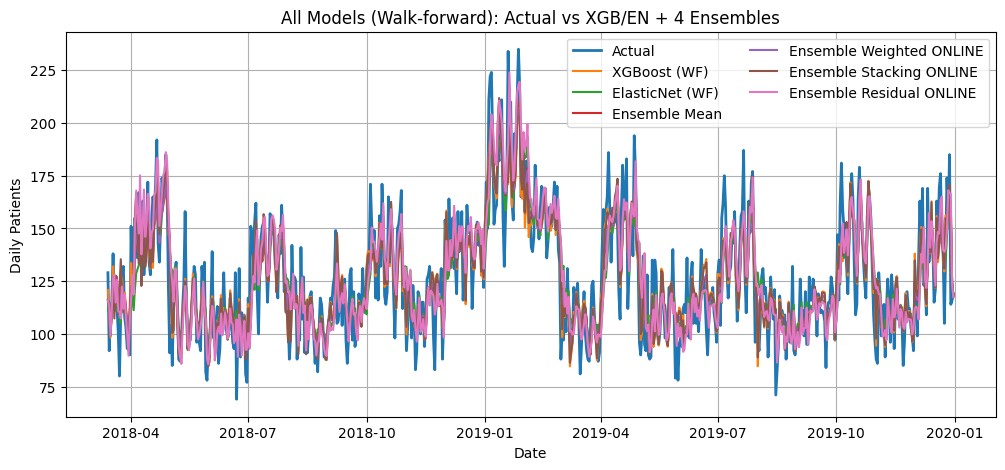


=== COMPARISON TABLE (sorted by MAE) ===

                   Model   N       MAE      RMSE        MSE       R2   MAPE(%)  sMAPE(%)
            XGBoost (WF) 658 11.367190 14.614365 213.579651 0.731879  9.280731  9.094728
Ensemble Stacking ONLINE 658 11.521909 14.855055 220.672653 0.722974  9.423522  9.232012
Ensemble Weighted ONLINE 658 11.694841 15.048682 226.462836 0.715705  9.598057  9.383232
           Ensemble Mean 658 11.772152 15.143037 229.311575 0.712129  9.664502  9.445911
Ensemble Residual ONLINE 658 13.024870 16.844249 283.728709 0.643815 10.670170 10.397606
         ElasticNet (WF) 658 13.334708 17.106630 292.636793 0.632633 10.960521 10.683926


In [18]:
# -----------------------------
# CELL 17) FINAL: Plot all together
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(dates, y_true, label="Actual", linewidth=2)
plt.plot(dates, p_xgb, label="XGBoost (WF)")
plt.plot(dates, p_en, label="ElasticNet (WF)")
plt.plot(dates, pred_mean, label="Ensemble Mean")
plt.plot(dates, pred_weighted_online, label="Ensemble Weighted ONLINE")
plt.plot(dates, pred_stack_online, label="Ensemble Stacking ONLINE")
plt.plot(dates, pred_residual_online, label="Ensemble Residual ONLINE")

plt.title("All Models (Walk-forward): Actual vs XGB/EN + 4 Ensembles")
plt.xlabel("Date")
plt.ylabel("Daily Patients")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

print("\n=== COMPARISON TABLE (sorted by MAE) ===\n")
print(results_table.to_string(index=False))


In [19]:
# -----------------------------
# CELL 18) Save the best model (XGBoost)
# -----------------------------
import joblib

final_model = make_xgb()
final_model.fit(ml_df[features], ml_df["y"])

joblib.dump(
    {
        "model": final_model,
        "features": features
    },
    "final_xgboost.pkl"
)

print("Final XGBoost model saved to final_xgboost.pkl")

Final XGBoost model saved to final_xgboost.pkl


In [20]:
from google.colab import files
files.download("final_xgboost.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>